# Эксперимент 06: BiLSTM по кадрам MFCC

**Статья:** A deep learning approach to dysarthric utterance classification with BiLSTM-GRU, speech cue filtering, and log mel spectrograms (Подход глубокого обучения к классификации дизартрической речи с BiLSTM-GRU, фильтрацией речевых признаков и log-mel спектрограммами) 2024

**Ссылка:** [https://link.springer.com/article/10.1007/s11227-024-06189-7](https://link.springer.com/article/10.1007/s11227-024-06189-7)

**Краткое описание модели:** Последовательность MFCC-кадров -> BiLSTM -> полносвязный классификатор.

**Содержание статьи:** Рекуррентные модели хорошо подходят для учета временной динамики артикуляции и просодии. В задаче дефектов речи это помогает ловить длительные зависимости, недоступные статическим признакам. BiLSTM-бейзлайн проверяет ценность двунаправленного контекста при классификации good/bad.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import time
from joblib import Parallel, delayed
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils
from shared.results_utils import save_result_csv
from model import get_model

## 1. Разбиение и извлечение последовательностей MFCC

In [ ]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

N_MFCC = config.N_MFCC
MAX_FRAMES = 320  # ~10 с при hop_length=512, sr=16k

def load_mfcc_seq(path):
    return data_utils.extract_mfcc_sequence(path, n_mfcc=N_MFCC, max_frames=MAX_FRAMES)

def build_seq_matrix(paths, n_jobs=-1):
    rows = Parallel(n_jobs=n_jobs)(delayed(load_mfcc_seq)(p) for p in paths)
    return np.stack(rows, axis=0).astype(np.float32)

print("Извлечение MFCC-последовательностей (train)...")
X_train = build_seq_matrix(paths_train, n_jobs=-1)
print("Val...")
X_val   = build_seq_matrix(paths_val, n_jobs=-1)
print("Test...")
X_test  = build_seq_matrix(paths_test, n_jobs=-1)
print(f"Форма: (N, time={MAX_FRAMES}, features={N_MFCC})")

Train: 1942, Val: 417, Test: 417
Извлечение MFCC-последовательностей (train)...
Val...
Test...
Форма: (N, time=320, features=20)


In [3]:
# Нормализация по признакам (mean/std по train)
feat_mean = X_train.reshape(-1, N_MFCC).mean(axis=0, keepdims=True)
feat_std  = X_train.reshape(-1, N_MFCC).std(axis=0, keepdims=True)
feat_std  = np.where(feat_std < 1e-6, 1.0, feat_std)
X_train = (X_train - feat_mean) / feat_std
X_val   = (X_val - feat_mean) / feat_std
X_test  = (X_test - feat_mean) / feat_std

## 2. DataLoader и модель

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 32
train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(letters_train).float(), torch.from_numpy(y_train).long())
val_ds   = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(letters_val).float(), torch.from_numpy(y_val).long())
test_ds  = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(letters_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Device: cuda


In [5]:
model = get_model(input_size=N_MFCC, num_classes=2, hidden_size=128, num_layers=2, n_letters=n_letters, dropout=0.3).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {n_params}")

Параметров: 549394


## 3. Обучение

In [6]:
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [7]:
def eval_loader(loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, letters, y in loader:
            x, letters, y = x.to(device), letters.to(device), y.to(device)
            logits = model(x, letters)
            pred = logits.argmax(dim=1)
            all_pred.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    return np.concatenate(all_pred), np.concatenate(all_true)

N_EPOCHS = 50
train_losses, val_f1s = [], []

t0 = time.perf_counter()
for epoch in range(N_EPOCHS):
    model.train()
    epoch_losses = []
    for x, letters, y in train_loader:
        x, letters, y = x.to(device), letters.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x, letters), y)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(np.mean(epoch_losses))
    vp, vt = eval_loader(val_loader)
    val_f1 = f1_score(vt, vp, average="macro")
    val_f1s.append(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  train_loss={train_losses[-1]:.4f}  val_f1_macro={val_f1:.4f}")
train_time_sec = time.perf_counter() - t0
print(f"Обучение заняло {train_time_sec:.1f} с.")

Epoch 1/50  train_loss=0.6395  val_f1_macro=0.6618
Epoch 2/50  train_loss=0.6153  val_f1_macro=0.6762
Epoch 3/50  train_loss=0.5969  val_f1_macro=0.6745
Epoch 4/50  train_loss=0.5933  val_f1_macro=0.7006
Epoch 5/50  train_loss=0.5796  val_f1_macro=0.6755
Epoch 6/50  train_loss=0.5657  val_f1_macro=0.6799
Epoch 7/50  train_loss=0.5538  val_f1_macro=0.6297
Epoch 8/50  train_loss=0.5470  val_f1_macro=0.6993
Epoch 9/50  train_loss=0.5305  val_f1_macro=0.6778
Epoch 10/50  train_loss=0.5444  val_f1_macro=0.6989
Epoch 11/50  train_loss=0.5129  val_f1_macro=0.6935
Epoch 12/50  train_loss=0.5243  val_f1_macro=0.6712
Epoch 13/50  train_loss=0.4969  val_f1_macro=0.6776
Epoch 14/50  train_loss=0.4567  val_f1_macro=0.6946
Epoch 15/50  train_loss=0.4548  val_f1_macro=0.6836
Epoch 16/50  train_loss=0.4316  val_f1_macro=0.6919
Epoch 17/50  train_loss=0.4153  val_f1_macro=0.6910
Epoch 18/50  train_loss=0.3706  val_f1_macro=0.6751
Epoch 19/50  train_loss=0.3821  val_f1_macro=0.6351
Epoch 20/50  train_lo

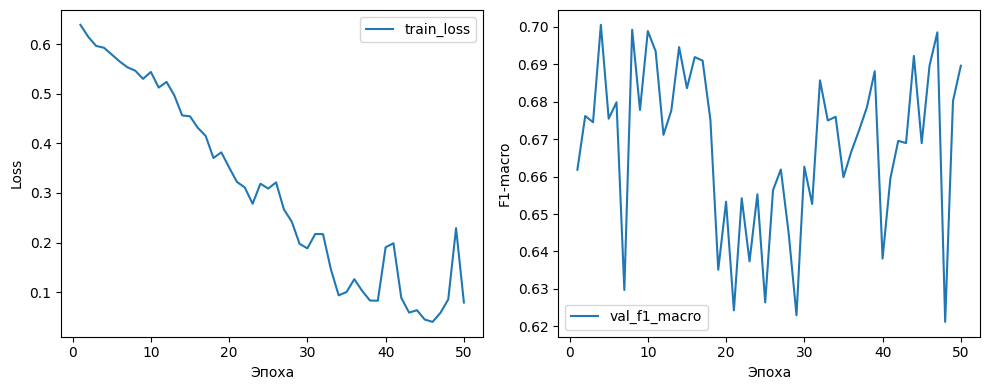

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, N_EPOCHS + 1), val_f1s, label="val_f1_macro")
plt.xlabel("Эпоха")
plt.ylabel("F1-macro")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Оценка на тесте и метрики

In [9]:
model.eval()
all_logits = []
with torch.no_grad():
    for x, letters, _ in test_loader:
        x, letters = x.to(device), letters.to(device)
        all_logits.append(model(x, letters).cpu().numpy())
logits = np.concatenate(all_logits)
y_pred = np.argmax(logits, axis=1)
y_proba = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

metrics_table = pd.DataFrame([{
    "accuracy": accuracy, "f1_macro": f1_macro, "f1_bad": f1_bad,
    "roc_auc": roc_auc, "precision_bad": precision_bad, "recall_bad": recall_bad,
}])
print("\nТаблица метрик (тест):")
display(metrics_table)

              precision    recall  f1-score   support

        good       0.77      0.79      0.78       282
         bad       0.54      0.52      0.53       135

    accuracy                           0.70       417
   macro avg       0.66      0.65      0.66       417
weighted avg       0.70      0.70      0.70       417

Accuracy: 0.7026
F1 macro: 0.6564
F1 (bad): 0.5303
ROC-AUC:  0.7170

Таблица метрик (тест):


,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.702638,0.65638,0.530303,0.717008,0.542636,0.518519


## 5. Запись метрик в общий файл

In [ ]:
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_06_lstm",
    experiment_name="BiLSTM по MFCC",
    model="BiLSTM (MFCC)",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes=f"n_mfcc={N_MFCC}, max_frames={MAX_FRAMES}, hidden=128, layers=2, epochs={N_EPOCHS}",
    num_params=n_params,
    train_time_sec=train_time_sec,
)